In [ ]:
! curl -s https://apertium.projectjj.com/apt/install-nightly.sh | sudo bash
! sudo apt-get install hfst lexd

Cleaning up old install, if any...
Determining Debian/Ubuntu codename...
Found evidence of jammy...
Settling for jammy - enabling the Apertium nightly repo...
Installing Apertium GnuPG key to /etc/apt/trusted.gpg.d/apertium.gpg
Installing package override to /etc/apt/preferences.d/apertium.pref
Creating /etc/apt/sources.list.d/apertium.list
Running apt-get update...
All done - enjoy the packages! If you just want all core tools, do: sudo apt-get install apertium-all-dev
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfoma0 libfst26 libhfst56 liblttoolbox3
The following NEW packages will be installed:
  hfst lexd libfoma0 libfst26 libhfst56 liblttoolbox3
0 upgraded, 6 newly installed, 0 to remove and 20 not upgraded.
Need to get 4,410 kB of archives.
After this operation, 23.3 MB of additional disk space will be used.
Get:1 http://apertium.projectjj.com/apt/nightly jammy/main amd64

In [ ]:
! git clone https://github.com/channrlotte/godoberi_transducer.git
%cd godoberi_transducer
! make all

Cloning into 'godoberi_transducer'...
remote: Enumerating objects: 247, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 247 (delta 136), reused 201 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (247/247), 476.38 KiB | 2.87 MiB/s, done.
Resolving deltas: 100% (136/136), done.
/content/godoberi_transducer/godoberi_transducer
lexd numerals.lexd | hfst-txt2fst -o numerals.hfst
lexd pronouns.lexd | hfst-txt2fst -o pronouns.hfst
cat adjectives/regular/m.txt adjectives/exceptions/m.txt adjectives/regular/f.txt adjectives/exceptions/f.txt adjectives/regular/n.txt adjectives/exceptions/n.txt adjectives/regular/hpl.txt adjectives/exceptions/hpl.txt adjectives/regular/npl.txt adjectives/exceptions/npl.txt adjectives/regular/common.txt adjectives/regular/obl_m.txt adjectives/exceptions/obl_m.txt adjectives/regular/obl_f.txt adjectives/exceptions/obl_f.txt adjectives/regular/obl_n.txt adjectives/exceptions/obl_n.txt

In [ ]:
import csv
import subprocess
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

In [ ]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]

base_color = "#172B62"

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

In [ ]:
def analyze(token: str):
    analysis = subprocess.run(
        ["hfst-lookup", "analyzer.hfstol"],
        input=token,
        text=True,
        encoding="utf-8",
        capture_output=True
    )

    for line in analysis.stdout.splitlines():
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        weight = parts[-1].strip()
        if weight != "inf":
            return tuple((a.split("\t")[1] for a in analysis.stdout.strip().splitlines()))

    return None

In [ ]:
tokens_saidova = []
coverage_saidova = []
tokens_kibrik = []
coverage_kibrik = []

In [ ]:
with open("texts_saidova.txt", "rt", encoding="utf-8") as f:
    for line in f.readlines():
        tokens_saidova.append(line.strip())

with open("text1_kibrik.csv", "rt", encoding="utf-8") as f:
    for line in csv.reader(f):
        if line[2] == "cyrillic":
            continue

        tokens_kibrik.append(line[2].replace("=", "").replace("-", ""))

In [ ]:
for tokens, coverage in zip((tokens_saidova, tokens_kibrik), (coverage_saidova, coverage_kibrik)):
    for token in tokens:
        if not analyze(token) is None:
            coverage.append(token)

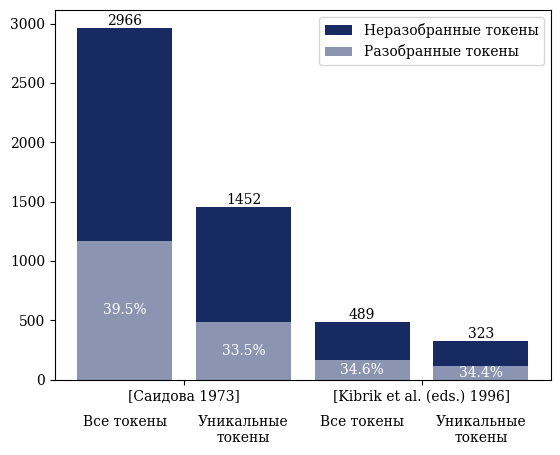

In [ ]:
x = np.arange(4)

covered = [len(coverage_saidova), len(set(coverage_saidova)), len(coverage_kibrik), len(set(coverage_kibrik))]
totals = [len(tokens_saidova), len(set(tokens_saidova)), len(tokens_kibrik), len(set(tokens_kibrik))]

plt.bar(x, totals, label="Неразобранные токены", color=base_color)
plt.bar(x, covered, label="Разобранные токены", color=lighten_color(base_color))

for i, total in enumerate(totals):
    covered_pct = covered[i] / total * 100

    plt.text(
        i,
        covered[i] / 2,
        f"{covered_pct:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=10
    )

    plt.text(
        i,
        total,
        f"{total}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks([0.5, 2.5], ["[Саидова 1973]", "[Kibrik et al. (eds.) 1996]"])

for i, sublabel in enumerate(["Все токены", "Уникальные\nтокены", "Все токены", "Уникальные\nтокены"]):
    plt.text(
        x[i],
        -max(totals) * 0.1,
        sublabel,
        ha="center",
        va="top",
        fontsize=10
    )

plt.legend()
plt.show()

In [ ]:
errors = {}
tokens = set()
recognised_token = 0
recognised_type = 0
tp_token = 0
tp_type = 0
fn_token = 0
fn_type = 0
fp_token = 0
fp_type = 0

In [ ]:
with open("text1_kibrik.csv", "rt", encoding="utf-8") as f:
    for line in csv.reader(f):
        if line[5] == "my_gloss":
            continue

        token = line[2].replace("=", "").replace("-", "")
        gold_standard = line[5]
        analysis = analyze(token)

        if analysis is None:
            fn_token += 1
            if token not in tokens:
                fn_type += 1

            if not gold_standard or not line[7]:
                continue

            for error in line[7].split(', '):
                lemma = gold_standard.split('>')[0][:-5]
                if error not in errors:
                    errors[error] = {}
                if lemma not in errors[error]:
                    errors[error][lemma] = []
                errors[error][lemma].append(gold_standard)

        else:
            recognised_token += 1
            if token not in tokens:
                recognised_type += 1

            if gold_standard in analysis:
                tp_token += 1
                if token not in tokens:
                    tp_type += 1
                if len(analysis) > 1:
                    fp_token += len(analysis) - 1
                    if token not in tokens:
                        fp_type += len(analysis) - 1

            elif not gold_standard:
                fp_token += 1
                if token not in tokens:
                    fp_type += 1

        tokens.add(token)

In [ ]:
accuracy_token = tp_token / recognised_token
accuracy_type = tp_type / recognised_type
precision_token = tp_token / (tp_token + fp_token)
precision_type = tp_type / (tp_type + fp_type)
recall_token = tp_token / (tp_token + fn_token)
recall_type = tp_type / (tp_type + fn_type)
f1_token = 2 * precision_token * recall_token / (precision_token + recall_token)
f1_type = 2 * precision_type * recall_type / (precision_type + recall_type)

In [ ]:
df_metrics = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1"],
    "Все токены": [accuracy_token, precision_token, recall_token, f1_token],
    "Уникальные токены": [accuracy_type, precision_type, recall_type, f1_type]
})

df_metrics.set_index("Метрика", inplace=True)

df_metrics

,Все токены,Уникальные токены
Метрика,,
Accuracy,0.982249,0.972973
Precision,0.813725,0.782609
Recall,0.341564,0.279070
F1,0.481159,0.411429


In [ ]:
rows = []

for error, lemmas in errors.items():
    error_analyses = []

    for lemma, analyses in lemmas.items():
        error_analyses.extend(analyses)

    rows.append({
        "Тип ошибки": error,
        "Количество лемм": f"{len(lemmas)} ({len(lemmas) / 34 * 100:.1f}%)",
        "Количество уникальных разборов":f"{len(set(error_analyses))} ({len(set(error_analyses)) / 61 * 100:.1f}%)" ,
        "Количество всех разборов": f"{len(error_analyses)} ({len(error_analyses) / 102 * 100:.1f}%)"
    })

df_errors = pd.DataFrame(rows)
df_errors.set_index("Тип ошибки", inplace=True)

df_errors

,Количество лемм,Количество уникальных разборов,Количество всех разборов
Тип ошибки,,,
orph,6 (17.6%),8 (13.1%),12 (11.8%)
morph,6 (17.6%),12 (19.7%),17 (16.7%)
abs,12 (35.3%),27 (44.3%),55 (53.9%)
part,8 (23.5%),11 (18.0%),12 (11.8%)
apoc,2 (5.9%),3 (4.9%),6 (5.9%)
